# [LAB-11] 1. 시계열 데이터의 이해

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helper import *

from pandas import DataFrame, Series
import numpy as np

# 데이터 정상성 확인을 위한 ADF 검정
from statsmodels.tsa.stattools import adfuller

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/
🔖 Version: 0.5.19


### 2. 데이터 불러오기

In [2]:
origin = load_data('air_passengers')
origin.head()

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)


,Month,Passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


### 3. 시계열 인덱스 설정

- **시계열 분석에서는 날짜/시간 값이 반드시 인덱스로 존재해야 한다.**
  - `Month` 컬럼은 이미 `datetime64` 타입이므로 형변환 없이 바로 인덱스로 지정하면 된다.
  - 만약 문자열이라면 `to_datetime()`으로 먼저 변환해야 한다.

In [3]:
df1 = origin.set_index("Month")

print("인덱스 타입:", type(df1.index))
df1.head()

인덱스 타입: <class 'pandas.DatetimeIndex'>


,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


## #02. 시계열의 첫 관찰

### 1. 시계열 시각화

- 시계열 분석은 **선 그래프**에서 시작한다.
- 검정 통계량보다 먼저, 눈으로 세 가지를 확인한다.

| 확인 항목 | 무엇을 보는가 |
|---|---|
| ① 추세 | 전체적으로 올라가는가, 내려가는가, 수평인가 |
| ② 계절성 | 일정한 주기로 같은 모양이 반복되는가 |
| ③ 변동폭 | 위아래로 흔들리는 폭이 시간이 지나며 **커지는가** |

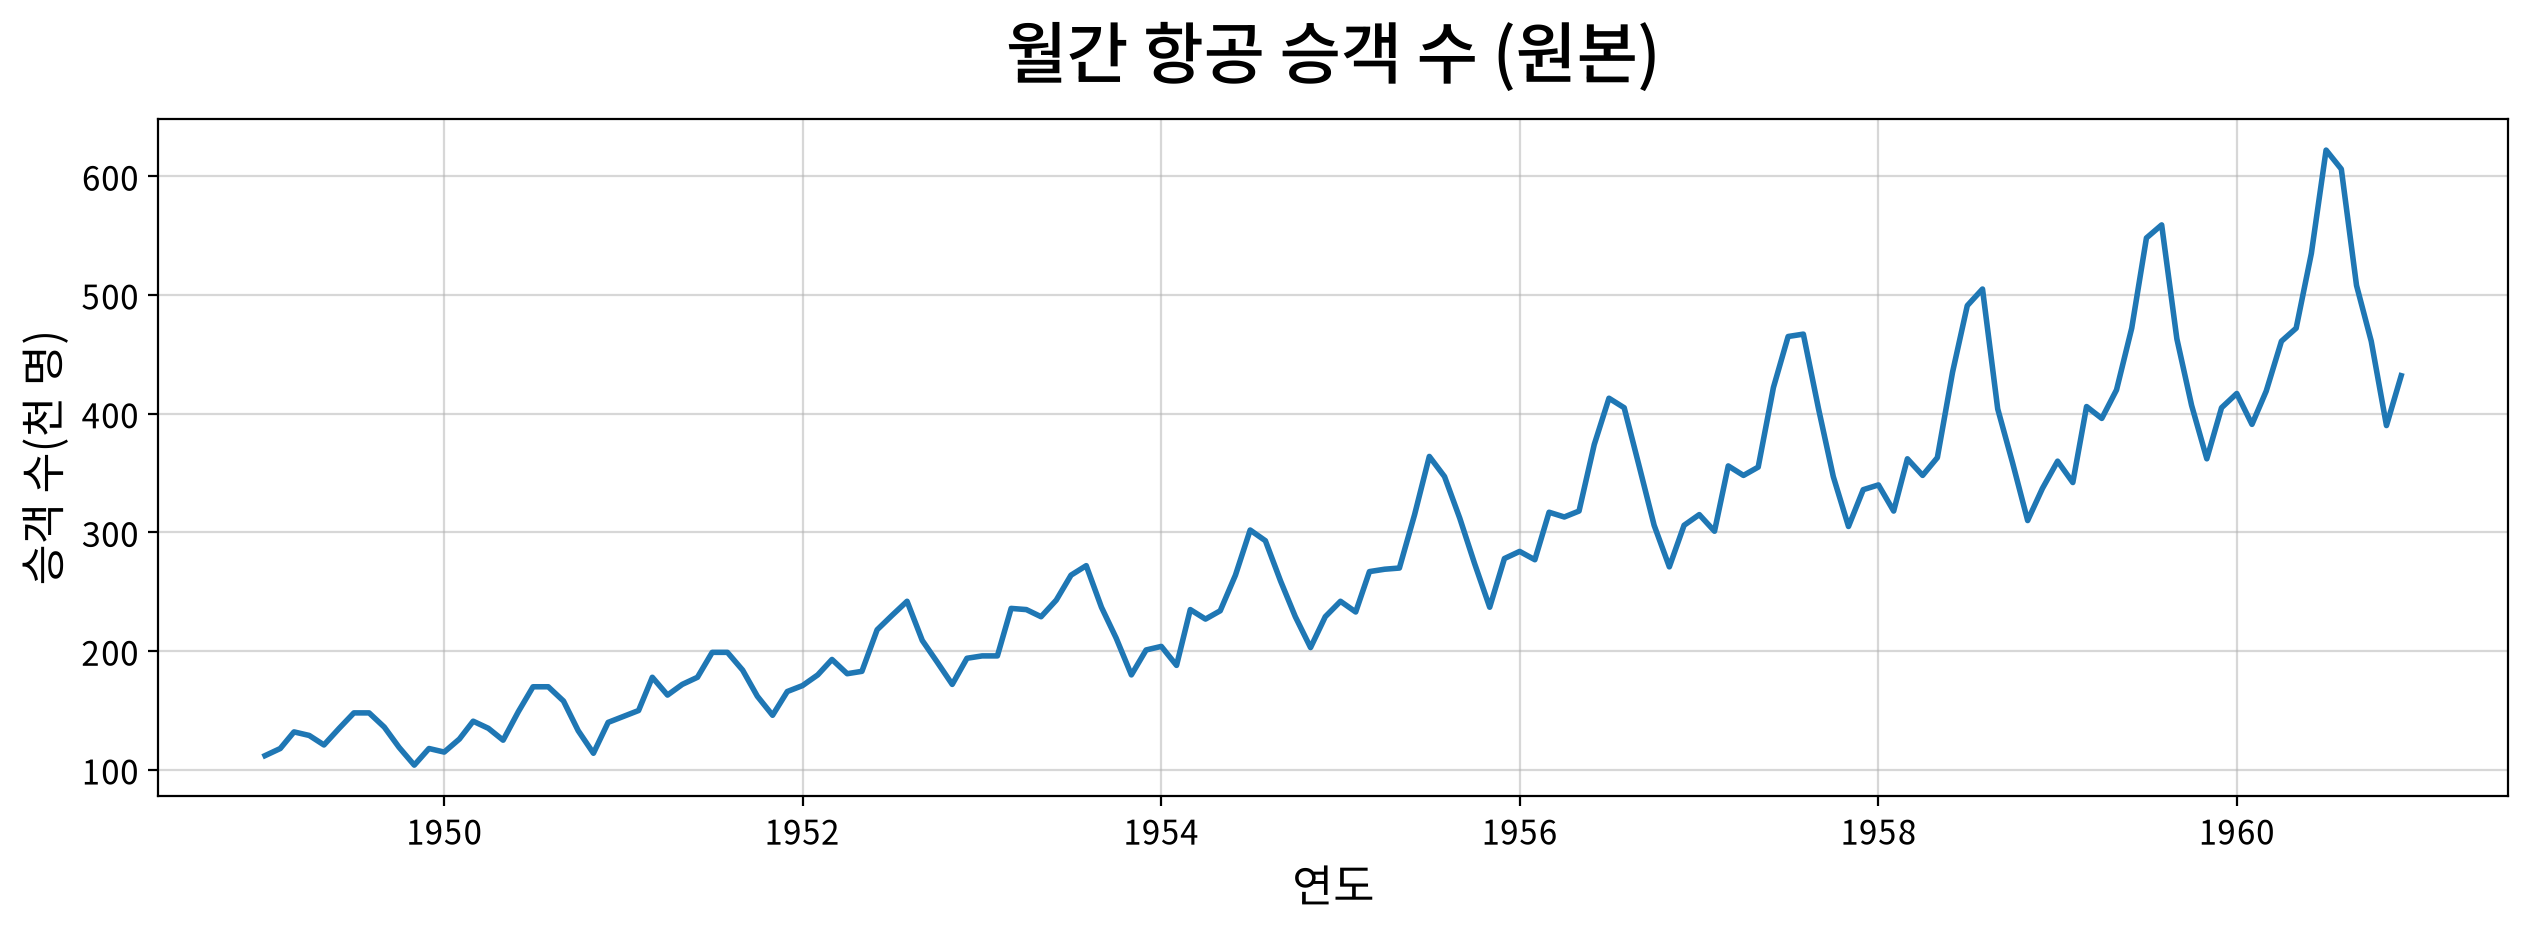

In [4]:
my_plot.lineplot(data=df1, x=df1.index, y="Passengers",
                 title="월간 항공 승객 수 (원본)",
                 xlabel="연도", ylabel="승객 수(천 명)",
                 width=1280, height=480)

#### 💡 인사이트

| 확인 항목 | 관찰 결과 |
|---|---|
| ① 추세 | 1949년 약 110에서 1960년 약 600까지 **뚜렷하게 우상향** |
| ② 계절성 | 매년 같은 모양의 봉우리가 반복 → **주기 12개월(1년)** 로 추정 |
| ③ 변동폭 | 초반에는 봉우리가 낮고 좁지만, **뒤로 갈수록 봉우리가 점점 커진다** |

- ③번이 특히 중요하다. 변동폭이 수준(level)에 **비례해서** 커지고 있다.
  승객이 100명일 때 여름 성수기 증가분과 500명일 때의 증가분이 절대량으로 다르다는 뜻이다.
- 즉 이 데이터는 **추세 + 계절성 + 변동폭 증가**라는 세 가지 문제를 한꺼번에 갖고 있다.
  세 가지는 각각 **다른 방법으로** 해결해야 한다.

## #03. 정상성(Stationarity) 확인

### 1. 구간을 나눠서 비교하기

- 정상성의 정의가 "어느 구간을 잘라도 비슷하였다"이므로, 실제로 잘라서 비교한다.
  - 3년간의 데이터이므로 3개 구간으로 나눈다.
  - 전체 데이터 길이에 대해 나누어 떨어지기만 하면 어느 숫자이건 상관 없음.

In [5]:
size = len(df1) // 3 # 데이터를 3개 구간으로 나눔
parts = []

for i in range(3):  # 구간수 만큼 반복
    # 구간의 시작 위치 (0*12, 1*12, 2*12) ~ 끝 위치 (1*12, 2*12, 3*12) 사이를 자름
    part = df1['Passengers'].iloc[i * size : (i + 1) * size]

    # 구간내 평균과 표준편차를 계산하여 리스트에 추가
    parts.append({
        "구간": f"구간 {i + 1}",
        "시작": part.index[0].strftime("%Y-%m"),
        "종료": part.index[-1].strftime("%Y-%m"),
        "평균": round(part.mean(), 2),
        "표준편차": round(part.std(), 2),
    })

DataFrame(parts)

,구간,시작,종료,평균,표준편차
0,구간 1,1949-01,1952-12,158.380,33.090
1,구간 2,1953-01,1956-12,269.040,55.730
2,구간 3,1957-01,1960-12,413.480,78.500


#### 💡 인사이트

- **평균**: 158 → 269 → 413 으로 계속 커진다. → **조건 ① 위반 (추세 존재)**
- **표준편차**: 33 → 56 → 79 로 함께 커진다. → **조건 ② 위반 (변동폭 증가)**

> 두 조건이 **동시에** 깨져 있으므로 **처방도 두 가지를 함께** 써야 한다.


### 2. 이동평균과 이동표준편차

- 3개 구간으로 나누는 대신 **1년(12개월)짜리 창을 옆으로 밀면서** 평균과 표준편차를 계산하면
변화의 모습을 연속적으로 볼 수 있다.
  - 3개 구간을 나누는 것과 같은 효과

TypeError: lineplot() got an unexpected keyword argument 'label'. Did you mean 'xlabel'?

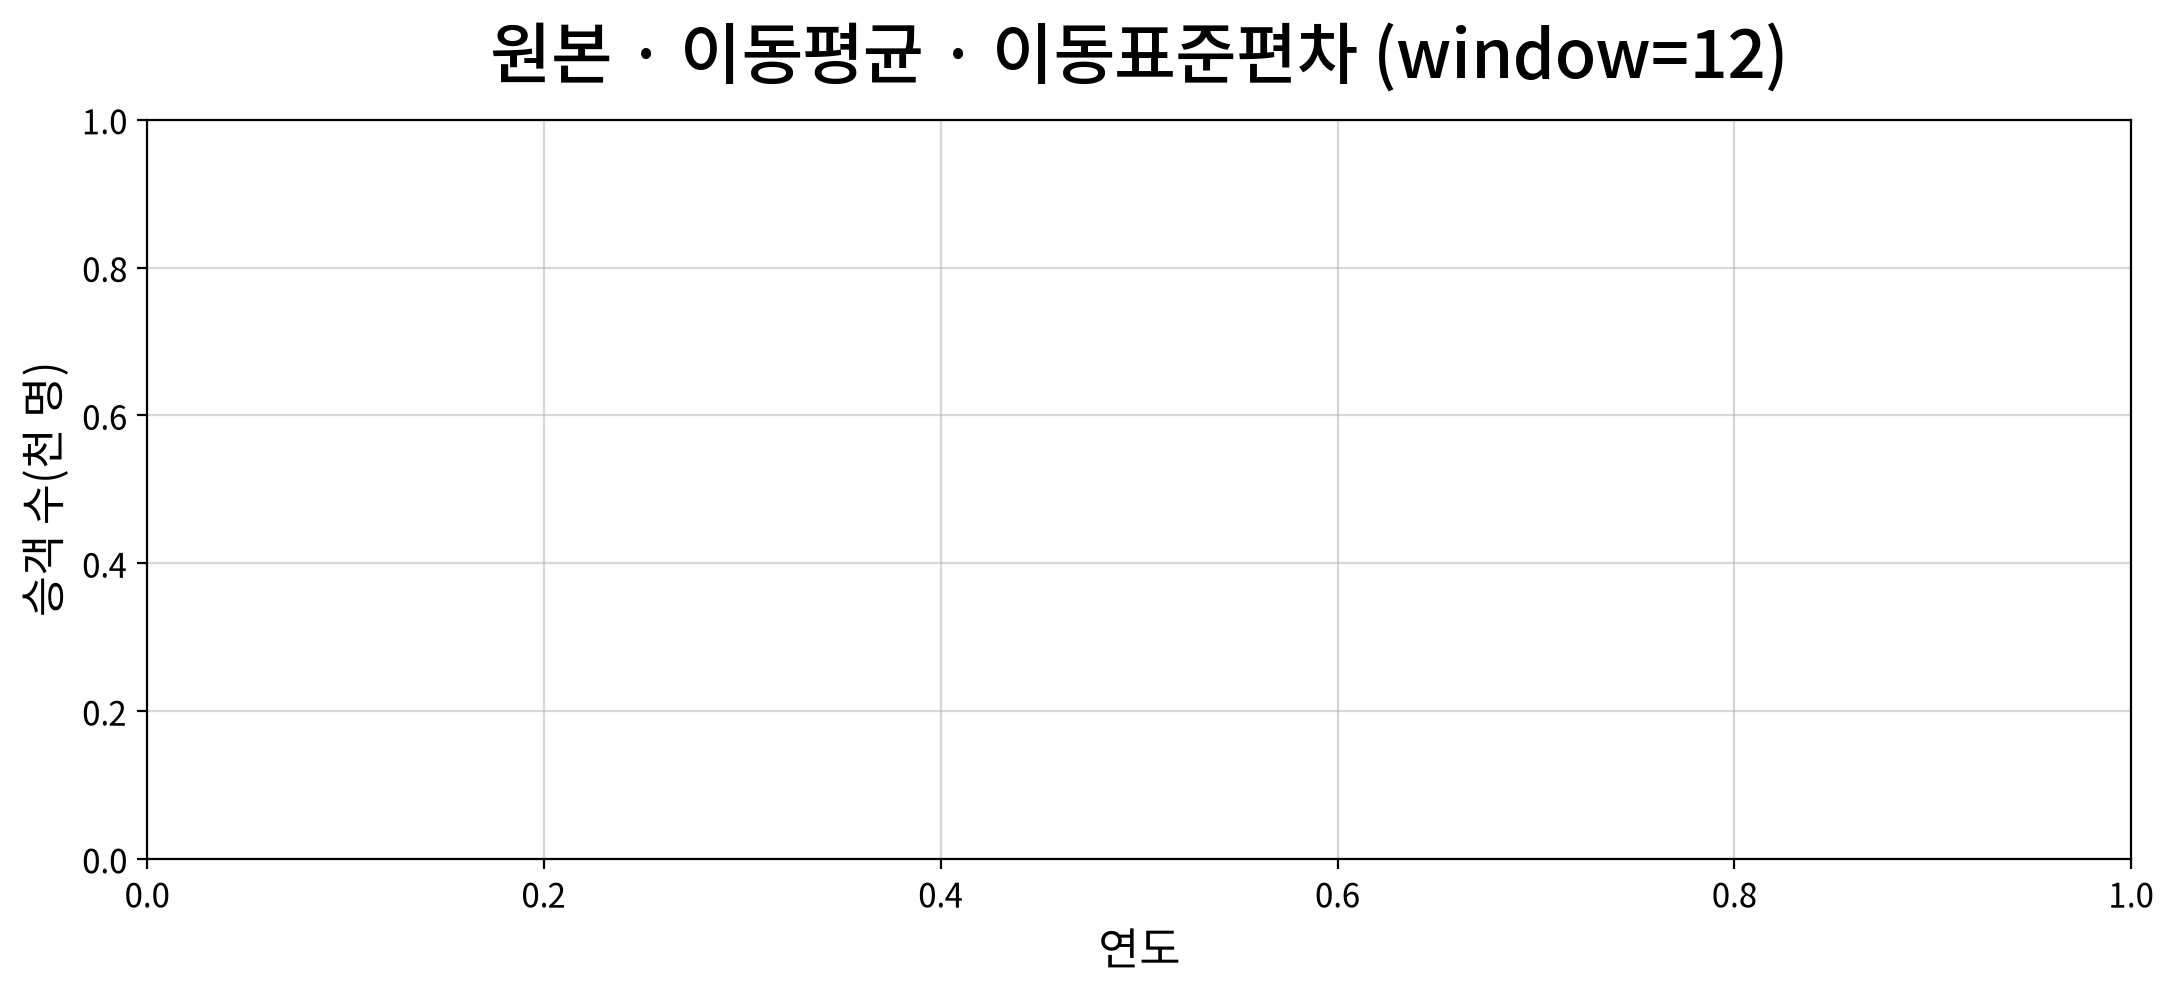

In [6]:
window = 12   # 월간 데이터이므로 1년 = 12개월

roll_mean = df1['Passengers'].rolling(window).mean()
roll_std  = df1['Passengers'].rolling(window).std()

fig, ax = my_plot.init(width=1280, height=480,
                       title=f"원본 · 이동평균 · 이동표준편차 (window={window})",
                       xlabel="연도", ylabel="승객 수(천 명)")

my_plot.lineplot(x=df1.index, y=df1['Passengers'], label="원본", ax=ax)
my_plot.lineplot(x=roll_mean.index, y=roll_mean, label="이동평균", ax=ax)
my_plot.lineplot(x=roll_std.index, y=roll_std, label="이동표준편차", ax=ax)

ax.legend()
my_plot.show()

#### 💡 인사이트

- **이동평균(주황)** 이 계속 우상향한다 → 평균이 일정하지 않다.
- **이동표준편차(초록)** 도 함께 우상향한다 → 분산이 일정하지 않다.

> 정상 시계열이라면 두 선 모두 **수평선**에 가까워야 한다.
> 이 그래프는 앞으로 전처리를 할 때마다 다시 그려서 **얼마나 수평에 가까워졌는지**를 확인하는 데 쓴다.

## #04. ADF 검정

### 1. 정상/비정상 데이터 샘플 만들기

| 이름 | 생성 방법 | $\phi$ | 성질 |
|---|---|---|---|
| 백색잡음 (White Noise) | 매번 독립적인 난수 | $\phi = 0$ | 정상 |
| 랜덤워크 (Random Walk) | 백색잡음의 **누적합** | $\phi = 1$ | 비정상 |

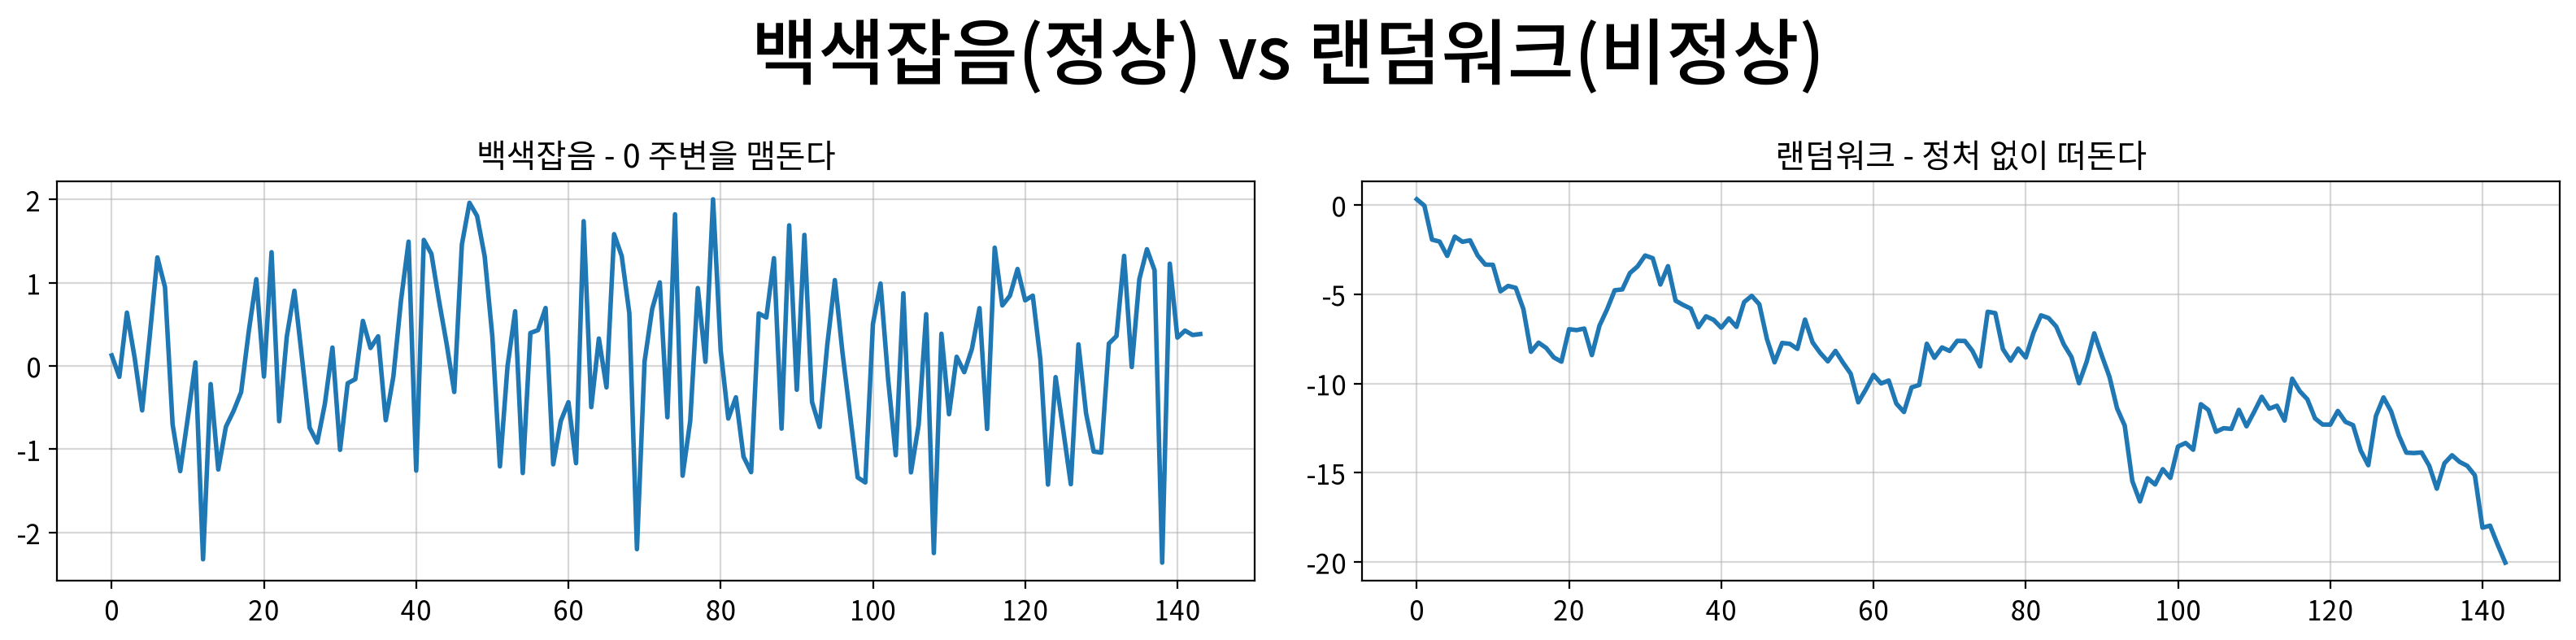

In [ ]:
rng = np.random.default_rng(0)   # 결과 재현을 위해 시드 고정

white_noise = rng.normal(0, 1, 144)                # 백색잡음
random_walk = np.cumsum(rng.normal(0, 1, 144))     # 랜덤워크 = 백색잡음의 누적합

fig, ax = my_plot.init(rows=1, cols=2, width=800, height=400,
                       title="백색잡음(정상) vs 랜덤워크(비정상)")

my_plot.lineplot(x=range(144), y=white_noise, ax=ax[0])
ax[0].set_title("백색잡음 - 0 주변을 맴돈다")

my_plot.lineplot(x=range(144), y=random_walk, ax=ax[1])
ax[1].set_title("랜덤워크 - 정처 없이 떠돈다")

my_plot.show()

#### 💡 인사이트

- **백색잡음**은 아무리 멀리 벗어나도 **0으로 되돌아온다.** 어느 구간을 잘라도 비슷하게 생겼다. → 정상
- **랜덤워크**는 한 번 움직이면 **그 자리에서 다시 출발한다.** 되돌아올 이유가 없으므로 구간마다 평균이 다르다. → 비정상

### 2. 정상성 검정 - 결과를 표로 만드는 함수 정의

`adfuller()`는 결과를 **튜플**로 돌려준다. 몇 번째에 무엇이 있는지 매번 외울 수 없으므로,
**필요한 값만 뽑아 딕셔너리로 돌려주는 함수**를 하나 만들어 두고 이 단원 내내 재사용한다.

In [ ]:
def adf_test(data, name):
    x = Series(data).dropna()                       # 결측치 제거
    stat, pvalue, lag, _, crit, _ = adfuller(x)     # ADF 검정 수행

    return {
        "대상": name,
        "관측치 수": len(x),
        "검정통계량(ADF)": round(stat, 3),      # 검정 통계량
        "p-value": round(pvalue, 3),          # p-value
        "사용 시차": lag,                      # 사용된 시차 수
        "1% 기각값": round(crit["1%"], 3),
        "5% 기각값": round(crit["5%"], 3),
        "10% 기각값": round(crit["10%"], 3),
        "판정": "정상" if pvalue < 0.05 else "비정상",
    }

### 3. 샘플 데이터에 대한 정상성 검정

In [ ]:
check = [
    adf_test(white_noise, "백색잡음 (정상일 것)"),
    adf_test(random_walk, "랜덤워크 (비정상일 것)"),

    # 차분1회 수행 --> 단순히 numpy.diff()를 사용하기만 하면 된다.
    adf_test(np.diff(random_walk), "랜덤워크의 1차 차분"),
]

DataFrame(check)[["대상", "검정통계량(ADF)", "p-value", "5% 기각값", "판정"]]

,대상,검정통계량(ADF),p-value,5% 기각값,판정
0,백색잡음 (정상일 것),-11.105,0.000,-2.882,정상
1,랜덤워크 (비정상일 것),-1.337,0.612,-2.882,비정상
2,랜덤워크의 1차 차분,-11.834,0.000,-2.882,정상


### 4. 실습 데이터의 정상성 검정

In [ ]:
r_origin = adf_test(df1["Passengers"], "원본")

Series(r_origin)

대상               원본
관측치 수           144
검정통계량(ADF)    0.815
p-value       0.992
사용 시차            13
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

#### 💡 인사이트

| 항목 | 값 | 해석 |
|---|---|---|
| 검정통계량 | **+0.815** | 양수다. 정상성의 증거가 전혀 없다 |
| p-value | **0.9919** | 0.05를 한참 넘는다 |
| 5% 기각값 | -2.884 | $0.815 > -2.884$ → 기각 실패 |

> **판정: 비정상.** 그래프에서 본 우상향 추세가 통계적으로도 확인되었다.
> 이제 이 데이터를 정상으로 만들어야 한다. 처방은 두 가지, **변환**과 **차분**이다.

## #05. 비정상 데이터 처방

### 1. 변환 (Transformation)

In [ ]:
log_s = np.log(df1['Passengers'])   # 로그변환

# 연도별 표준편차 계산
std_origin = df1['Passengers'].groupby(df1.index.year).std()
std_log    = log_s.groupby(df1.index.year).std()

compare_std = DataFrame({
    "원본 표준편차": std_origin.round(2),
    "로그 표준편차": std_log.round(4),
})
compare_std.index.name = "연도"

display(compare_std)

print(f"원본  - 최대/최소 비율: {std_origin.max() / std_origin.min():.2f}배")
print(f"로그  - 최대/최소 비율: {std_log.max() / std_log.min():.2f}배")

,원본 표준편차,로그 표준편차
연도,,
1949,13.720,0.108
1950,19.070,0.135
1951,18.440,0.108
1952,22.970,0.113
1953,28.470,0.128
1954,34.920,0.144
1955,42.140,0.144
1956,47.860,0.141
1957,57.890,0.152


원본  - 최대/최소 비율: 5.67배
로그  - 최대/최소 비율: 1.48배


#### 💡 인사이트

| 구분 | 1949년 | 1960년 | 최대/최소 비율 |
|---|---|---|---|
| 원본 | 13.72 | 77.74 | **5.67배** |
| 로그변환 | 0.108 | 0.157 | **1.48배** |

> 원본은 연도별 변동폭이 **5.67배**나 차이 났지만, 로그변환 후에는 **1.48배**로 줄었다.
> 완벽하게 같아지지는 않았지만 **"분산이 일정하다"고 볼 수 있는 수준**에 도달했다.

### 2. 로그변환 결과 확인

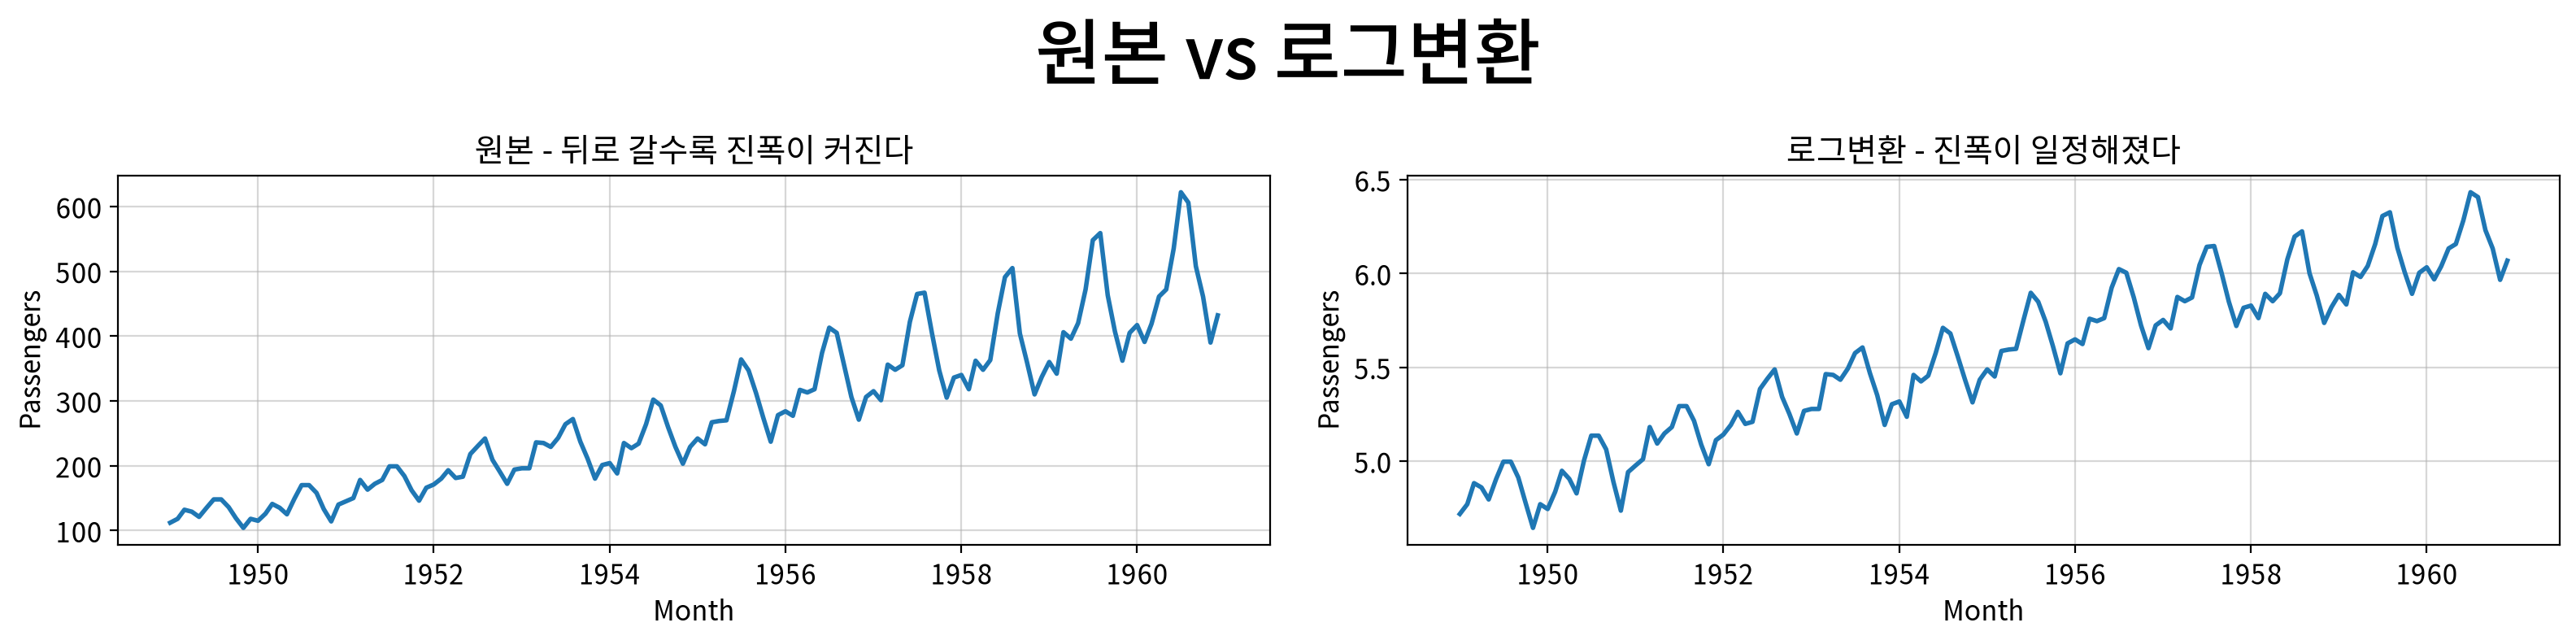

{'대상': '로그변환',
 '관측치 수': 144,
 '검정통계량(ADF)': np.float64(-1.717),
 'p-value': np.float64(0.422),
 '사용 시차': 13,
 '1% 기각값': np.float64(-3.482),
 '5% 기각값': np.float64(-2.884),
 '10% 기각값': np.float64(-2.579),
 '판정': '비정상'}

In [ ]:
fig, ax = my_plot.init(rows=1, cols=2, width=800, height=400,
                       title="원본 vs 로그변환")

my_plot.lineplot(x=df1.index, y=df1['Passengers'], ax=ax[0])
ax[0].set_title("원본 - 뒤로 갈수록 진폭이 커진다")

my_plot.lineplot(x=log_s.index, y=log_s, ax=ax[1])
ax[1].set_title("로그변환 - 진폭이 일정해졌다")

my_plot.show()

# 로그 변환에 대한 ADF 검정 결과
r_log = adf_test(log_s, "로그변환")
r_log

#### 💡 인사이트

- 오른쪽 그래프의 봉우리 높이가 **처음부터 끝까지 거의 같아졌다.** → 조건 ② 해결
- 하지만 **여전히 우상향한다.** → 조건 ① 은 그대로 남아 있다
- p-value가 0.9919 → **0.4219** 로 크게 좋아졌지만 여전히 0.05를 넘는다.
- 검정통계량도 +0.815 → **-1.717** 로 개선되었으나 5% 기각값(-2.884)에 못 미친다.

> 크게 좋아졌으나 기각값에 못 미친다    
> → 로그변환은 분산만 잡는다. 추세는 손대지 못한다.    
> 추세를 없애려면 차분이 필요하다


### 3. 차분 수행

In [ ]:
# 차분 수행 --> 차분의 결과로 발생하는 결측치는 제거한다.
df2 = df1.diff().dropna()

print(f"원본 {len(df1)}개 → 1차 차분 {len(df2)}개 (첫 행 소실)")
df2.head()

원본 144개 → 1차 차분 143개 (첫 행 소실)


,Passengers
Month,
1949-02-01,6.000
1949-03-01,14.000
1949-04-01,-3.000
1949-05-01,-8.000
1949-06-01,14.000


### 4. 차분 결과 시각화 및 ADF 검정

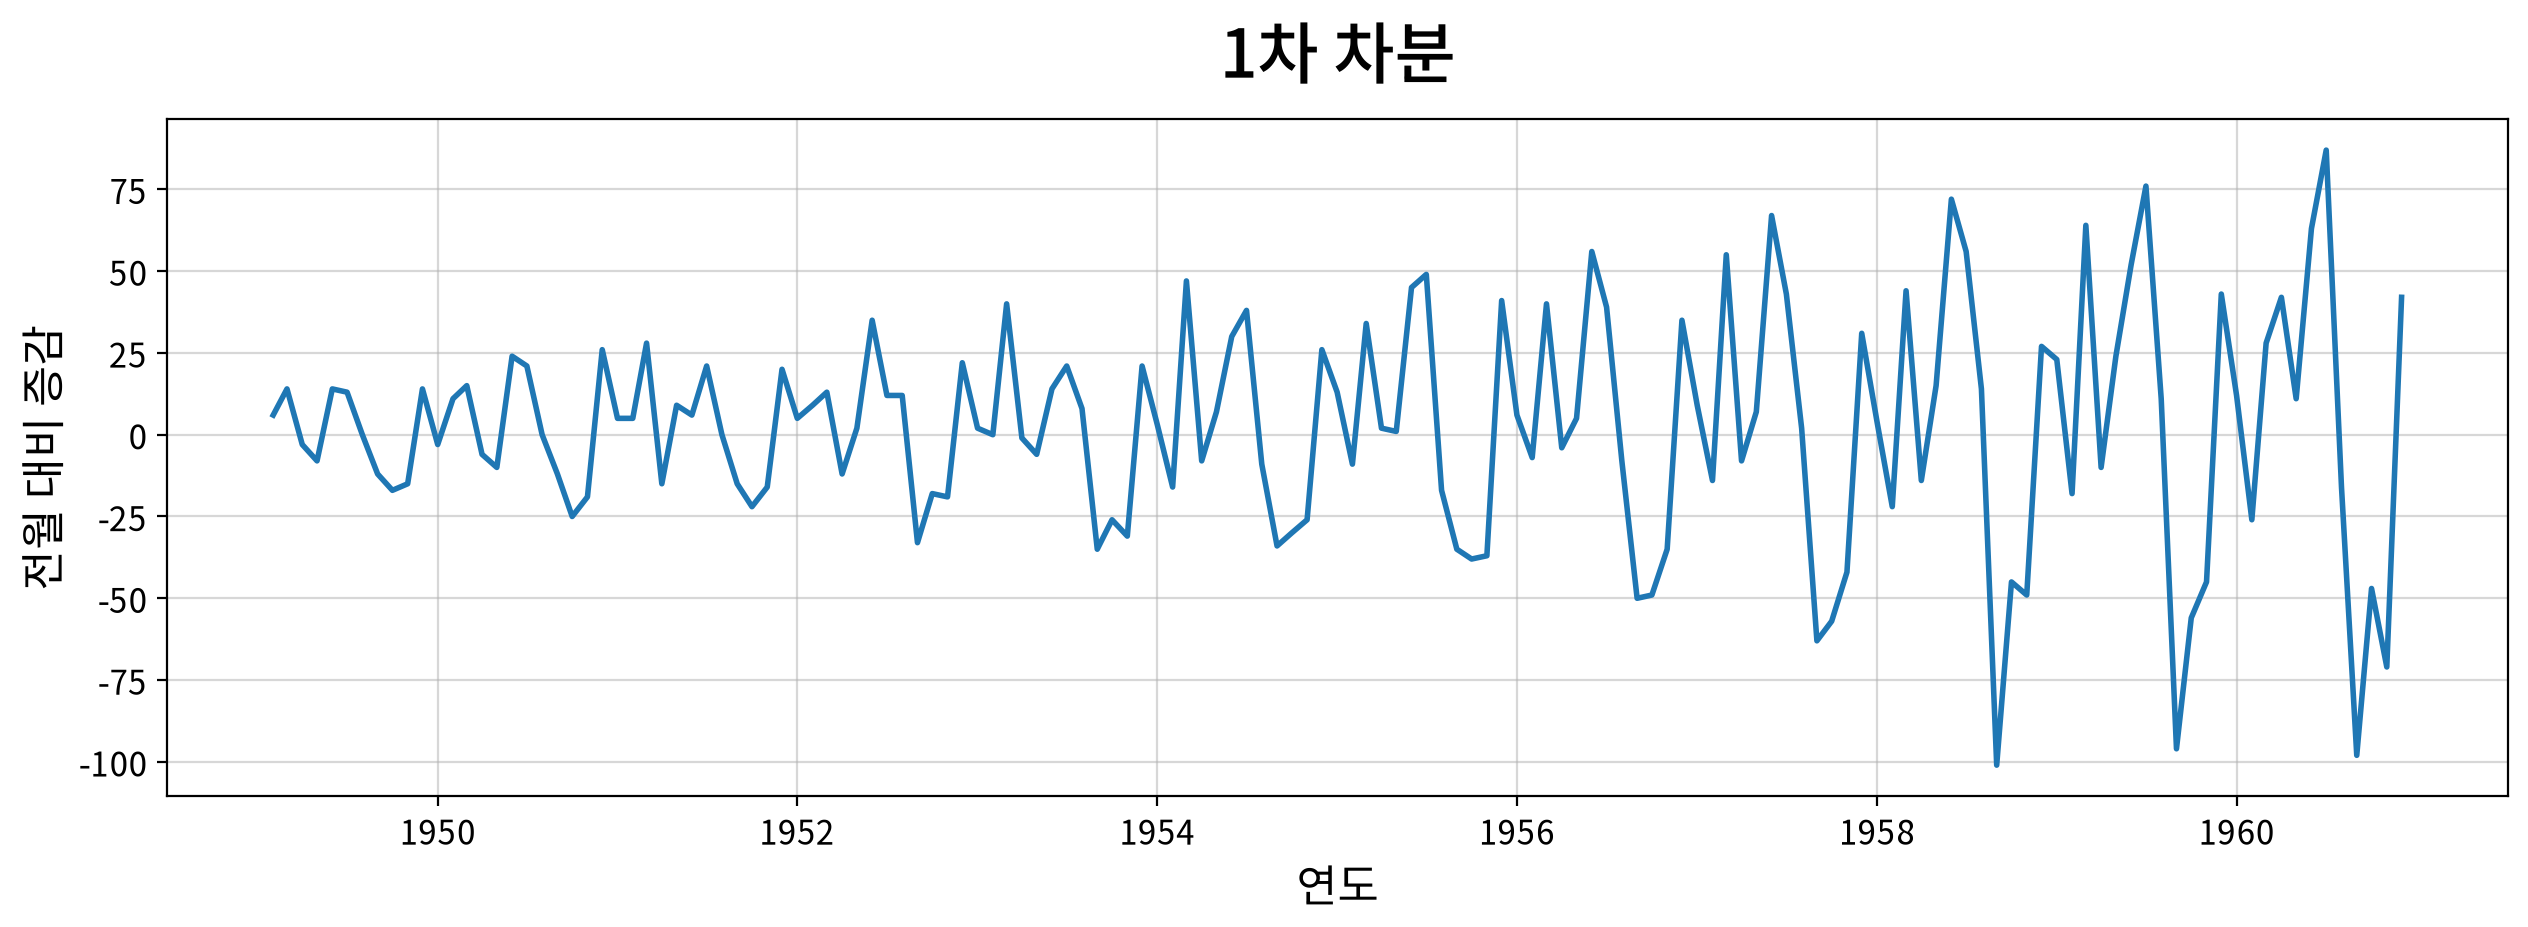

대상            1차 차분
관측치 수           143
검정통계량(ADF)   -2.829
p-value       0.054
사용 시차            12
1% 기각값       -3.482
5% 기각값       -2.884
10% 기각값      -2.579
판정              비정상
dtype: object

In [ ]:
my_plot.lineplot(data=df2, x=df2.index, y="Passengers",
                 title="1차 차분",
                 xlabel="연도", ylabel="전월 대비 증감",
                 width=1280, height=480)

r_d1 = adf_test(df2["Passengers"], "1차 차분")

Series(r_d1)

#### 💡 인사이트

- 그래프가 **0을 중심으로 위아래로 움직인다.** 우상향 추세가 사라졌다. → 조건 ① 해결
- 그런데 **뒤로 갈수록 진폭이 커진다.** 분산 문제는 그대로 남아 있다. → 조건 ② 미해결
- p-value = **0.0542**. 0.05를 **아슬아슬하게 넘는다.**

### 5. 2차 차분 실험

차분을 한 번 더 해보고, 차수별로 **표준편차가 어떻게 변하는지** 관찰한다.

In [ ]:
over_diff = []                   # 차분 횟수별 ADF 검정 결과를 담을 리스트
tmp = df1["Passengers"].copy()   # 원본 데이터를 복사하여 차분 수행

for i in range(4):               # 0차 ~ 3차 차분까지 반복
    r = adf_test(tmp, f"{i}차 차분" if i > 0 else "원본")   # ADF 검정 수행
    r["표준편차"] = round(tmp.std(), 2)                     # 표준편차 계산
    over_diff.append(r)         # 결과를 리스트에 추가
    tmp = tmp.diff().dropna()   # 다음 차분을 위해 1차 차분 수행 후 결측치 제거

DataFrame(over_diff)[["대상", "관측치 수", "검정통계량(ADF)", "p-value", "판정", "표준편차"]]

,대상,관측치 수,검정통계량(ADF),p-value,판정,표준편차
0,원본,144,0.815,0.992,비정상,119.970
1,1차 차분,143,-2.829,0.054,비정상,33.750
2,2차 차분,142,-16.384,0.000,정상,39.860
3,3차 차분,141,-9.435,0.000,정상,60.980


#### 💡 인사이트 - 이 표가 이 단원에서 가장 중요하다

| 차수 | p-value | 표준편차 | 판단 |
|---|---|---|---|
| 원본 | 0.9919 | 119.97 | 비정상 |
| 1차 차분 | 0.0542 | **33.75** ← 최소 | 경계선 |
| 2차 차분 | 0.0000 | 39.86 ↑ | 정상이지만 분산 증가 |
| 3차 차분 | 0.0000 | 60.98 ↑↑ | 분산 폭증 |

- **p-value만 보면 2차·3차 차분이 좋아 보인다.** 0에 가까울수록 정상성이 강하니까.
- 그러나 **표준편차는 1차 차분에서 최소값(33.75)을 찍고 다시 커진다.**
- 표준편차가 커진다는 것은 **데이터에 없던 노이즈를 만들어냈다**는 뜻이다.
  차분은 이웃한 값의 차이를 구하는 연산이므로, 반복하면 무작위 오차가 증폭된다.

> ★ **과대차분 판별 규칙: 표준편차가 최소가 되는 차수를 넘기지 않는다.**
>
> 과대차분된 데이터로 ARIMA를 만들면 계수 추정이 불안정해지고 예측 구간이 쓸데없이 넓어진다.
> **p-value를 낮추는 것이 목적이 아니다. 필요한 만큼만 차분하는 것이 목적이다.**

그렇다면 1차 차분(p=0.0542)의 남은 문제는 어떻게 풀어야 하는가?
**차분 횟수를 늘리는 대신, 남아 있는 문제인 계절성과 분산을 직접 처리한다.**

### 6. 계절차분 (Seasonal Differencing)

- pandas에서는 `diff(12)`로 간단히 수행한다. 앞의 12개 행이 결측치가 된다.

In [ ]:
df3 = df1["Passengers"].diff(12).dropna()

my_plot.lineplot(x=df3.index, y=df3, title="계절차분 (작년 같은 달 대비 증감)",
                 xlabel="연도", ylabel="전년 동월 대비 증감",
                 width=1280, height=480)

r_ds = adf_test(df3, "계절차분(12)")    # ADF 검정 수행
Series(r_ds)

NameError: name 'df1' is not defined

## #06. 전처리 조합 비교 - 무엇을 쓸 것인가

### 1. 전처리 파이프라인

- 지금까지 배운 세 가지 도구(로그변환 / 일반차분 / 계절차분)를 조합해 한꺼번에 비교한다.
  - 조합을 **딕셔너리 하나로 정의**해 두고 반복문으로 검정만 돌리면 된다.
  - `diff()`가 일반차분, `diff(12)`가 계절차분이므로 **메서드를 이어 붙이면 그대로 조합이 된다.**

In [ ]:
s = df1["Passengers"]
ls = np.log(s)

combos = {
    "① 원본": s,
    "② 1차 차분": s.diff(),
    "③ 2차 차분": s.diff().diff(),
    "④ 로그변환": ls,
    "⑤ 로그 + 1차 차분": ls.diff(),
    "⑥ 계절차분(12)": s.diff(12),
    "⑦ 로그 + 계절차분(12)": ls.diff(12),
    "⑧ 로그 + 1차 차분 + 계절차분(12)": ls.diff().diff(12),
}

### 2. 조합 비교

In [ ]:
report = []     # ADF 검정 결과를 담을 리스트

for name, x in combos.items():  # combos 딕셔너리의 key, value를 순회
    r = adf_test(x, name)       # ADF 검정 수행
    r["표준편차"] = round(x.dropna().std(), 3)  # 표준편차 계산
    report.append(r)            # 결과를 리스트에 추가

# ADF 검정 결과를 데이터프레임으로 변환하여 출력
DataFrame(report)[["대상", "관측치 수", "검정통계량(ADF)", "p-value", "5% 기각값", "표준편차", "판정"]]

,대상,관측치 수,검정통계량(ADF),p-value,5% 기각값,표준편차,판정
0,① 원본,144,0.815,0.992,-2.884,119.966,비정상
1,② 1차 차분,143,-2.829,0.054,-2.884,33.754,비정상
2,③ 2차 차분,142,-16.384,0.000,-2.884,39.856,정상
3,④ 로그변환,144,-1.717,0.422,-2.884,0.441,비정상
4,⑤ 로그 + 1차 차분,143,-2.717,0.071,-2.884,0.107,비정상
5,⑥ 계절차분(12),132,-3.383,0.012,-2.884,17.655,정상
6,⑦ 로그 + 계절차분(12),132,-2.710,0.072,-2.886,0.062,비정상
7,⑧ 로그 + 1차 차분 + 계절차분(12),131,-4.443,0.000,-2.886,0.046,정상


## #07. 모듈화 기능 확인

### 1. 데이터 로딩 후 시계열 인덱스 설정

In [7]:
origin = load_data('air_passengers')

# 날짜 컬럼명만 알려주면 된다
df = my_ts.set_index(origin, "Month")

print("인덱스 타입:", type(df.index))

📚 어느 항공사의 월간 탑승객 수 (출처: https://www.kaggle.com/datasets/rakannimer/air-passengers)
인덱스 타입: <class 'pandas.DatetimeIndex'>


### 2. 구간별 비교

In [8]:
# 구간을 3개로 나눠 비교 (#03-1 과 같은 표)
my_ts.report_split(df, "Passengers", size=3)

,시작,종료,관측치 수,평균,표준편차,변동계수
구간,,,,,,
구간 1,1949-01-01,1952-12-01,48,158.375,33.086,0.209
구간 2,1953-01-01,1956-12-01,48,269.042,55.731,0.207
구간 3,1957-01-01,1960-12-01,48,413.479,78.498,0.190


### 3. 기간별 비교

In [9]:
# 연도별로 묶어 변동폭 비교 (#05-1 과 같은 판단)
# freq="YE" → 연말 기준 1년씩 / "QE" → 분기씩 / "ME" → 월말 기준 한 달씩
#      "WE" → 주말 기준 1주일씩 / "D" → 하루씩
my_ts.report_variation(df, "Passengers", freq="YE")

표준편차 최대/최소 : 5.67배
변동계수 최대/최소 : 1.56배
판정: 변동폭이 수준에 비례한다 → 로그변환 권장 / 승법(multiplicative) 모델


,평균,표준편차,변동계수
기간,,,
1949-12-31,126.667,13.720,0.108
1950-12-31,139.667,19.071,0.137
1951-12-31,170.167,18.438,0.108
1952-12-31,197.000,22.966,0.117
1953-12-31,225.000,28.467,0.127
1954-12-31,238.917,34.924,0.146
1955-12-31,284.000,42.140,0.148
1956-12-31,328.250,47.862,0.146
1957-12-31,368.417,57.891,0.157


### 4. ADF 검정

In [10]:
my_ts.adf_test(df, "Passengers")

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
Passengers,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상


### 5. 시계열 데이터 변환

In [11]:
# 로그변환 → 1차 차분 → 계절차분(12) 을 한 번에 적용한다
log_diff = my_ts.transform(df, "Passengers", 
                           log=True, diff=1, seasonal_diff=1, period=12)

# 변환 결과에 대한 ADF 검정 수행
my_ts.adf_test(log_diff, name="로그 + 1차 차분 + 계절차분(12)")

,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상


### 6. 최적의 차분 회수 판정

In [12]:
# 차수를 늘려가며 검정한다. 표준편차가 최소인 차수에 ★ 가 찍힌다
my_ts.adf_diff(df, "Passengers", max_diff=3)

권장 차분 차수: 1차 차분 (표준편차가 최소인 지점)
⚠️ 1차 차분은 아직 비정상입니다(p-value 0.0542). 차분을 더 늘리지 말고 로그변환·계절차분으로 남은 구조를 처리하세요. → adf_transform()


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정,권장
원본,144,0.815,0.992,13,-3.482,-2.884,-2.579,119.966,False,비정상,
1차 차분,143,-2.829,0.054,12,-3.482,-2.884,-2.579,33.754,False,비정상,* 여기까지
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상,과대차분
3차 차분,141,-9.435,0.000,14,-3.483,-2.885,-2.579,60.984,True,정상,과대차분


### 7. 자동 전처리 및 결과 검정

In [13]:
# 로그 여부(2) × 일반차분 0~2회(3) × 계절차분 0~1회(2) = 12가지 조합을 자동 생성해 검정한다
# 결과표는 함수가 직접 출력하고, 권장 조합을 적용한 시계열이 반환된다
best = my_ts.adf_transform(df, "Passengers", period=12, max_diff=2)

best.head(3)

조합 12개 중 정상 7개
권장 전처리: 로그변환 + 1차 차분 + 계절차분(12)


,관측치 수,검정통계량(ADF),p-value,사용 시차,1% 기각값,5% 기각값,10% 기각값,표준편차,정상성,판정
로그변환 + 1차 차분 + 계절차분(12),131,-4.443,0.000,12,-3.487,-2.886,-2.580,0.046,True,정상
로그변환 + 2차 차분 + 계절차분(12),130,-4.305,0.000,10,-3.487,-2.886,-2.580,0.075,True,정상
로그변환 + 2차 차분,142,-8.197,0.000,13,-3.483,-2.884,-2.579,0.135,True,정상
1차 차분 + 계절차분(12),131,-15.596,0.000,0,-3.482,-2.884,-2.579,12.357,True,정상
계절차분(12),132,-3.383,0.012,1,-3.482,-2.884,-2.579,17.655,True,정상
2차 차분 + 계절차분(12),130,-8.098,0.000,7,-3.485,-2.886,-2.580,20.072,True,정상
2차 차분,142,-16.384,0.000,11,-3.482,-2.884,-2.579,39.856,True,정상
로그변환 + 계절차분(12),132,-2.710,0.072,12,-3.487,-2.886,-2.580,0.062,False,비정상
로그변환 + 1차 차분,143,-2.717,0.071,14,-3.483,-2.884,-2.579,0.107,False,비정상
로그변환,144,-1.717,0.422,13,-3.482,-2.884,-2.579,0.441,False,비정상


Month
1950-02-01    0.039
1950-03-01    0.000
1950-04-01   -0.020
Name: 로그변환 + 1차 차분 + 계절차분(12), dtype: float64